In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
model = ChatOpenAI()

In [5]:
# State
class BlogAgentState(TypedDict):
    user_query: str
    topic: str
    outline: str
    final_blog: str

In [8]:
# Create Blog writer agent

def generate_topic(state: BlogAgentState) -> BlogAgentState:
    prompt = f"Generate blog topic based on user query : {state["user_query"]}"
    
    llm_response = model.invoke(prompt).content
    
    state["topic"] = llm_response
    return state
    
def generate_outline(state: BlogAgentState) -> BlogAgentState:
    prompt = f"Generate blog outline based on topic: {state["topic"]}"
    
    llm_response = model.invoke(prompt).content
    
    state["outline"] = llm_response
    
    return state

def generate_blog(state: BlogAgentState) -> BlogAgentState:
    prompt = f'''Generate blog based on topic and outline: 
    topic: {state["topic"]}
    outline: {state["outline"]}'''
    
    llm_response = model.invoke(prompt).content
    
    state["final_blog"] = llm_response
    return state


In [9]:
# define graph
graph = StateGraph(BlogAgentState)

# define Nodes
graph.add_node('generate_topic', generate_topic)
graph.add_node('generate_outline', generate_outline)
graph.add_node('generate_blog', generate_blog)

# add edges
graph.add_edge(START, "generate_topic")
graph.add_edge("generate_topic", "generate_outline")
graph.add_edge("generate_outline", "generate_blog")
graph.add_edge("generate_blog", END)

# compile
workflow = graph.compile()

#invoke
initial_state = {"user_query":"react useEffect"}
updated_state = workflow.invoke(initial_state)
print(updated_state)

{'user_query': 'react useEffect', 'topic': 'Title: Understanding the React useEffect Hook: A Comprehensive Guide\n\nIntroduction:\nIn the world of React programming, the useEffect hook plays a crucial role in managing side effects in functional components. In this blog post, we will delve deep into the useEffect hook, its usage, and how you can leverage it to optimize your React applications.\n\nKey points to be covered:\n1. What is the useEffect hook and why is it important in React?\n2. How to use the useEffect hook in functional components\n3. Managing side effects with useEffect: fetching data, updating the DOM, and more\n4. Understanding dependencies and cleanup in useEffect\n5. Best practices for using useEffect in your React applications\n6. Real-world examples and use cases of the useEffect hook\n7. Tips for optimizing performance with useEffect\n\nConclusion:\nBy mastering the useEffect hook, you can enhance the functionality and performance of your React applications. This co

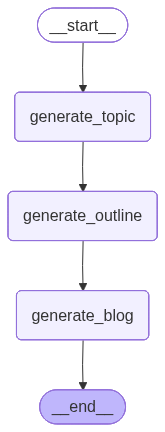

In [10]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())